# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida


**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.



In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('plans.csv')
users = pd.read_csv('users_latam.csv') #completa el código
usage = pd.read_csv('usage.csv') #completa el código

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum()) # Cantidad de valores nulos)
print(users.isna().mean()) # Proporción de valores nulos)

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Dataset users:**

* La columna churn_date, que representa la fecha en que el cliente canceló el servicio cuenta con 88.3% de nulos, lo que significa que, la gran mayoría de los clientes siguen activos y por lo tanto se deben ignorar y mantener como nulos, ya que los valores nulos tienen el significado de cliente activo.

* La columna city cuenta con 11.7% de nulos, lo que significa que falta la ubicación de un segmento considerable de usuarios. Lo mejor sería investigar para imputar, y revisar si los datos pueden recuperarse  de alguna manera o dejar como "NaN" para no perder esos registros en el análisis.

**Dataset usage:**

* La columna duration cuenta con 55.1% de nulos y la columna length cuenta con un 44.7% de nulos. Esto podría significar, que existe una pérdida masiva de datos, pero visualizando las primeras 5 filas, podemos observar que en la columna de duration, hay nulos en length porque en las llamadas no hay longitud de texto, y, en la columna de length hay nulos en duration, porque los mensajes no tienen una duración. Si este fuera el caso, estaríamos ante nulos MAR y la ausencia de datos está dependiendo de estas variables entre sí, por lo cual, no sería necesario imputarlos.

* La columna date cuenta con 0.12% de nulos, lo que significa que la falta de fechas es insignificante (solo 50 registros). Lo recomendable sería eliminar esos registros o Imputar. Al ser menor al 5%, se podrían borrar esas filas sin afectar la estadística general del dataset.


**En conclusión:**

* churn_date: El nulo es información valiosa  al representar la lealtad del cliente).

* city: Una pérdida del 11% es manejable y permite segmentación si se clasifica como "No especificado"o "Unknown".

* duration / length: El alto porcentaje de nulos, se debe a que dependen de otra variable (nulos MAR) y no es necesario imputarlos.

* date: El impacto en la muestra total es poco relevante y pueden ser eliminados.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
columnas_numericas = ['user_id','age']
print('Resumen estadístico de las columnas numéricas de users')
print(users[columnas_numericas].describe())
print()#Salto de Línea
print('Medianas:')
print(users[columnas_numericas].median())

Resumen estadístico de las columnas numéricas de users
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000

Medianas:
user_id    11999.5
age           47.0
dtype: float64


- La columna `user_id`cuenta con valores consistentes, la media y mediana son iguales, los valores mínimos y máximos no se disparan entre sí, no se cuenta con valores nulos o faltantes.
- La columna `age` cuenta con un sentinel -999 que se aprecía en el valor mínimo, y el cual, tambíen esta afectando la desviación estandar, al contar un valor más alto de lo normal. Eso siginifica que se estan estirando los datos debido a este valor extremo.

In [ ]:
# explorar columnas numéricas de usage
columnas_numericas = ['id','user_id','duration','length']
print('Resumen estadístico de las columnas numéricas de usage')
print(usage[columnas_numericas].describe())
print()#Salto de Línea
print('Medianas:')
print(usage[columnas_numericas].median())

Resumen estadístico de las columnas numéricas de usage
                id       user_id      duration        length
count  40000.00000  40000.000000  17924.000000  22104.000000
mean   20000.50000  12002.405975      5.202237     52.127398
std    11547.14972   1157.279564      6.842701     56.611183
min        1.00000  10000.000000      0.000000      0.000000
25%    10000.75000  10996.000000      1.437500     37.000000
50%    20000.50000  12013.000000      3.500000     50.000000
75%    30000.25000  13005.000000      6.990000     64.000000
max    40000.00000  13999.000000    120.000000   1490.000000

Medianas:
id          20000.5
user_id     12013.0
duration        3.5
length         50.0
dtype: float64


- Las columnas `id` y `user_id`, no cuentan con valores nulos, sus valores máximos y mínimos concuerdan con el número de datos totales (4000), y sus desviaciones estandar confirman que los IDs están bien distribuidos.
- La columna `duration` cuenta con valores nulos, y un valor maximo de 120 minutos (outlier) que puede estar aumentando el valor de la media.
- La columna `length` también cuenta con valores nulos, y un valor máximo de 1490 caracteres, que podría tratarse de un outlier.

In [ ]:
# explorar columnas categóricas de users
columnas_users = ['city', 'plan']
print(users[columnas_users].describe())
print()
print("Frecuencia absoluta:")
print(users[columnas_users].value_counts())
print("\nFrecuencia relativa:")
print(users[columnas_users].value_counts(normalize=True))

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595

Frecuencia absoluta:
city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

Frecuencia relativa:
city      plan   
Bogotá    Basico     0.147833
CDMX      Basico     0.134240
Medellín  Basico     0.112716
GDL       Basico     0.084395
Bogotá    Premium    0.080997
MTY       Basico     0.077882
Cali      Basico     0.074200
CDMX      Premium    0.072501
Medellín  Premium    0.061739
Cali      Premium    0.045879
GDL       Premium    0.043047
MTY       Premium    0.037383
?         Basico     0.018408
          Premium    0.008779
dtype: float64


- La columna `city` cuenta con valores nulos, así como 7 valores únicos de los cuales la ciudad de Bógota es la más popular y hay un sentinel representado por el valor "?", en 96 registros (65 en plan Básico y 31 en Premium).
- La columna `plan` solo cuenta con 2 valores únicos, y ningún valor nulo, siendo el plan Básico el más popular.

In [ ]:
# explorar columna categórica de usage
print(usage['type'].describe()) # completa el código
print()
print("Frecuencia absoluta:")
print(usage['type'].value_counts())
print("\nFrecuencia relativa:")
print(usage['type'].value_counts(normalize=True))

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

Frecuencia absoluta:
text    22092
call    17908
Name: type, dtype: int64

Frecuencia relativa:
text    0.5523
call    0.4477
Name: type, dtype: float64


- La columna `type` no cuenta con valores nulos y Está balanceada entre "text" con un 55.2% y "call" con un 44.7%, sin valores extraños a simple vista.

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

**Se identificaron sentinels en dos columnas críticas:**

- age (users): El valor -999 se utilizó para registros de edades desconocidas.

- city (users): El valor "?" se utilizó para registros donde no se capturó la ciudad del usuario.

- ¿Qué acción tomarías?

- Para la columna `age` sería recomendable remplazar el valor "-999" por la mediana (47),  ya que la media esta afectada por este valor extremo.

- Para la columna `city` sería recomendable remplazar el valor "?" por la etiqueta "Unknown" o "No especificado", y así poder mantener los registros para el análisis sin que afecten las estadísticas por ciudad.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce") # completa el código

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce") # completa el código

In [ ]:
# Revisar los años presentes en `reg_date` de users
print("Conteo de años en reg_date (users):")
# Usamos .dt.year para extraer solo el año y value_counts() para ver la frecuencia
print(users['reg_date'].dt.year.value_counts().sort_index())

Conteo de años en reg_date (users):
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, se observa que los registros están principalmente distribuidos entre 2022, 2023 y 2024. Sin embargo, se detectaron 40 registros en el año 2026. Dado que se cuentan con datos registrados hasta el año 2024, estos 40 registros se identifican como fechas con errores de captura y deberán ser tratados o eliminados.

In [ ]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


En `date`, se observa que el 100% de los registros válidos corresponden al año 2024, y por lo cual, no presenta anomalías de años futuros o pasados.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  
Observando los datos sí aparecen años sin transcurrir. Mientras que la mayoría de los datos se concentran entre 2022 y 2024, se detectaron 40 registros en el año 2026. Dado que la documentación del proyecto establece que el límite de los datos recolectados es el año 2024, estas fechas se consideran errores de captura o inconsistencias del sistema.

- ¿Qué harías con ellas?

Recomendaría filtrar y eliminar estos 40 registros del análisis de usuarios. Al ser una cantidad mínima (menos del 1% de la base), su eliminación no afecta la representatividad estadística, pero sí previene errores en el cálculo de métricas temporales como la antigüedad del cliente o el análisis de cohortes.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999,pd.NA)
users['age'] = users['age'].fillna(age_mediana)
# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?",pd.NA)
# Verificar cambios
print(users['city'].describe())
print()
print(users['city'].value_counts())

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT
# 2. Verificar cambios
print(users['reg_date'].describe())
print("\nConteo de años actualizado:")
print(users['reg_date'].dt.year.value_counts().sort_index())

count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

Conteo de años actualizado:
2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
nulos_duration_type = usage["duration"].isna().groupby(usage["type"]).mean()
print(nulos_duration_type)

type
call    0.000000
text    0.999276
Name: duration, dtype: float64


In [ ]:
# Verificación MAR en usage (Missing At Random) para length
nulos_length_type = usage["length"].isna().groupby(usage["type"]).mean()
print(nulos_length_type)

type
call    0.99933
text    0.00000
Name: length, dtype: float64


Haz doble clic aquí y escribe que tu diagnostico de nulos en `duration` y `length`

**Diagnóstico:**

* Tras analizar la distribución de valores nulos mediante una agrupación por la columna type, se confirma que la falta de datos en duration y length es de naturaleza MAR (Missing At Random).

* Se puede observar una correlación casi perfecta: las filas de tipo 'text' (mensajes) no poseen 'duration' porque los mensajes no tienen una duración temporal, mientras que las filas de tipo 'call' (llamadas) no poseen 'length' porque las llamadas no tienen una longitud de caracteres.

* Por lo cual, los nulos representan la ausencia lógica de una métrica según el tipo de servicio, y la recomendación es dejarlos como nulos. Imputar estos valores, crearía inconsistencias técnicas y sesgaría el análisis de los promedios reales de cada servicio.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call":"sum",
    "duration":"sum"}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={'is_text':'cant_mensajes', 'is_call': 'cant_llamadas', 'duration': 'total_minutos_llamada'})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,total_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on=['user_id'], how='left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,total_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
user_profile = user_profile.fillna({
    'cant_mensajes': 0,
    'cant_llamadas': 0,
    'total_minutos_llamada': 0,
})
print("Resumen estadístico por usuario durante 2024 (activos+inactivos)")
print()
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'total_minutos_llamada']
print(user_profile[columnas_numericas].describe())
print()
print(user_profile[columnas_numericas].median())

Resumen estadístico por usuario durante 2024 (activos+inactivos)

               age  cant_mensajes  cant_llamadas  total_minutos_llamada
count  4000.000000    4000.000000    4000.000000            4000.000000
mean     48.122250       5.523000       4.477000              23.311225
std      17.690408       2.359738       2.145139              18.169564
min      18.000000       0.000000       0.000000               0.000000
25%      33.000000       4.000000       3.000000              11.107500
50%      47.000000       5.000000       4.000000              19.780000
75%      63.000000       7.000000       6.000000              31.412500
max      79.000000      17.000000      15.000000             155.690000

age                      47.00
cant_mensajes             5.00
cant_llamadas             4.00
total_minutos_llamada    19.78
dtype: float64


In [ ]:
# Distribución porcentual del tipo de plan
print("Distribución porcentual del tipo de plan:")
print()

#Frecuencia absoluta (conteo)
print("Frecuencia absoluta:")
plan_counts = user_profile['plan'].value_counts()
print(plan_counts)
print()

#Frecuencia relativa (porcentajes)
print("Frecuencia relativa (porcentajes):")
plan_porcentajes = user_profile['plan'].value_counts(normalize=True)*100
print(plan_porcentajes.round(2))

Distribución porcentual del tipo de plan:

Frecuencia absoluta:
Basico     2595
Premium    1405
Name: plan, dtype: int64

Frecuencia relativa (porcentajes):
Basico     64.88
Premium    35.12
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

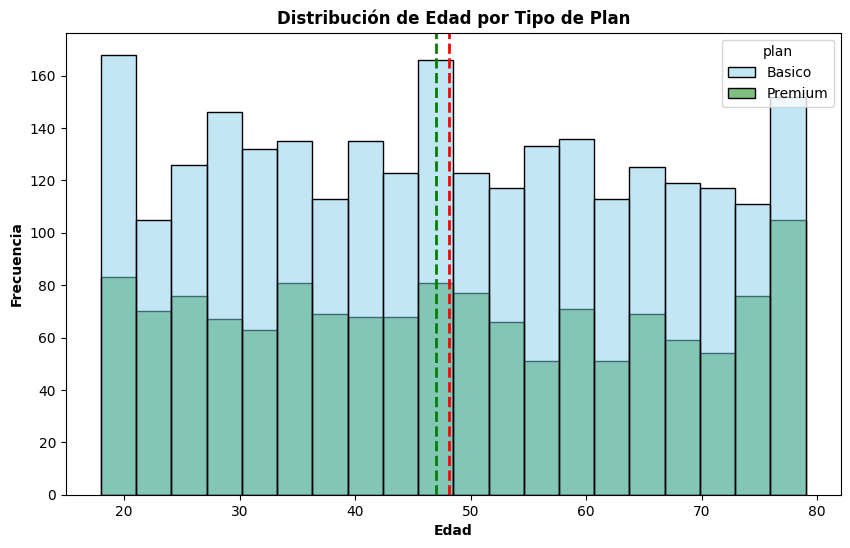

In [ ]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(10,6))
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'], bins=20)

media_age = user_profile['age'].mean()
mediana_age =user_profile['age'].median()

plt.axvline(media_age, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(mediana_age, color='green', linestyle='dashed', linewidth=2, label='Mediana')

plt.title('Distribución de Edad por Tipo de Plan',fontweight='bold')
plt.xlabel('Edad',fontweight='bold')
plt.ylabel('Frecuencia',fontweight='bold')
plt.show()

💡Insights:

* La distribución de usuarios con planes básicos y premium se observa estable y uniforme a lo largo de todos los rangos de edad, desde los 20 hasta los 80 años. Se puede concluir que no existe un patrón de edad marcado por tipo de plan.
* Media ligeramente superior a la mediana, lo que indica que los valores extremos tienen poco impacto en las métricas centrales.

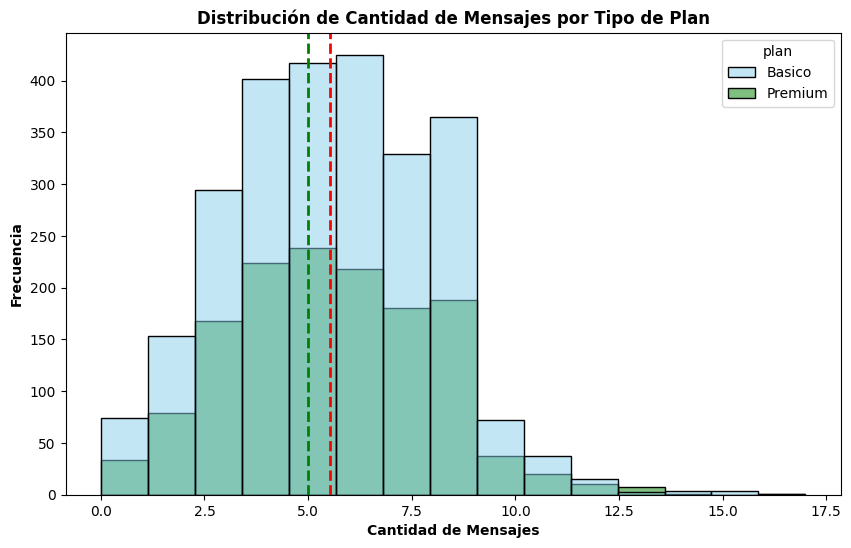

In [ ]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10,6))
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'], bins=15)

media_cant_msjs = user_profile['cant_mensajes'].mean()
mediana_cant_msjs =user_profile['cant_mensajes'].median()

plt.axvline(media_cant_msjs, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(mediana_cant_msjs, color='green', linestyle='dashed', linewidth=2, label='Mediana')

plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan',fontweight='bold')
plt.xlabel('Cantidad de Mensajes',fontweight='bold')
plt.ylabel('Frecuencia',fontweight='bold')
plt.show()

💡Insights:

* Se observa una distribución con sesgo a la derecha. Los datos se agrupan principalmente hacia la izquierda, suele haber muchos usuarios con una cantidad moderada de mensajes y una minoría con un uso muy intensivo, lo que indica que el uso de SMS es ocasional para la mayoría de los segmentos.
* La mayoría de los usuarios, independientemente de su plan, realizan entre 3 y 7 mensajes. El plan Básico tiene una mayor frecuencia absoluta de usuarios en el pico de la gráfica, pero su comportamiento es casi idéntico al del plan Premium.

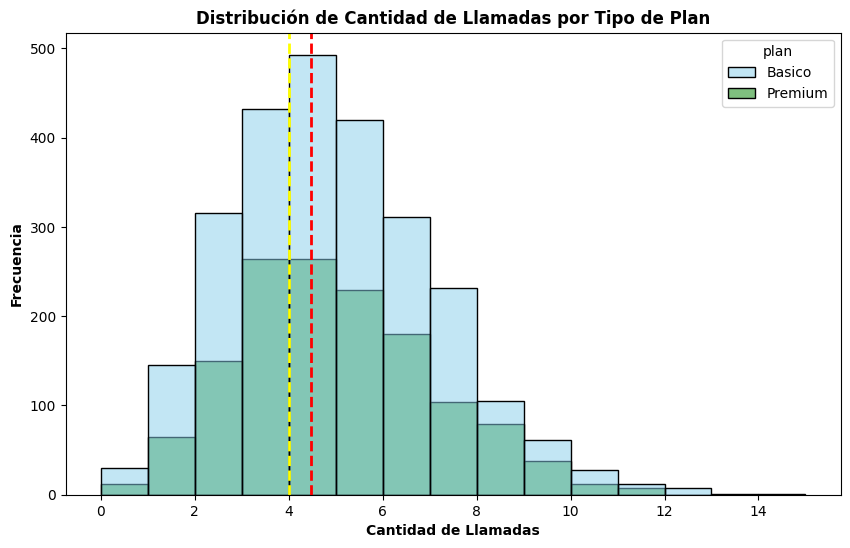

In [ ]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10,6))
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'], bins=15)

media_cant_llam = user_profile['cant_llamadas'].mean()
mediana_cant_llam =user_profile['cant_llamadas'].median()

plt.axvline(media_cant_llam, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(mediana_cant_llam, color='yellow', linestyle='dashed', linewidth=2, label='Mediana')

plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan',fontweight='bold')
plt.xlabel('Cantidad de Llamadas',fontweight='bold')
plt.ylabel('Frecuencia',fontweight='bold')
plt.show()

💡Insights:

- Se puede observar una distribución simétrica con sesgo a la derecha.
- La mayoría de los usuarios, independientemente de su plan, realizan entre 3 y 6 llamadas. El plan Básico tiene una mayor frecuencia de usuarios pero su  comportamiento es casi idéntico al del plan Premium.

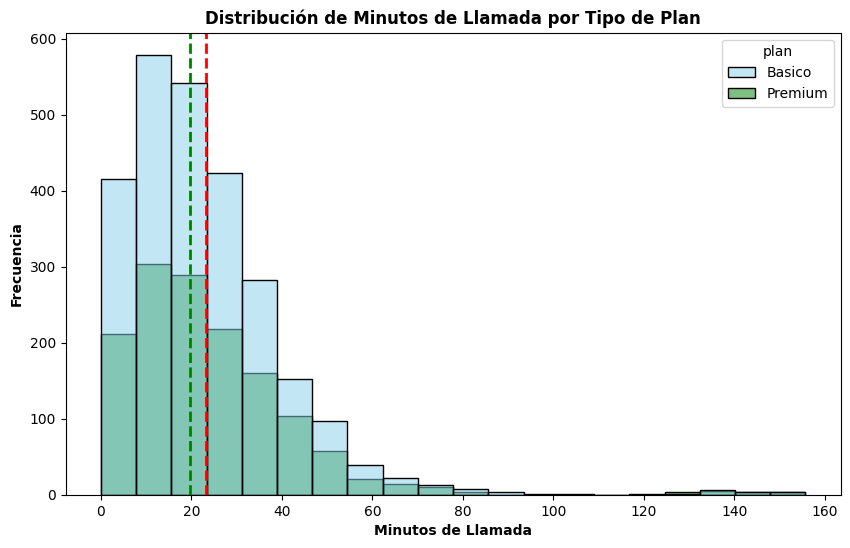

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10,6))
sns.histplot(data=user_profile, x='total_minutos_llamada', hue='plan', palette=['skyblue','green'], bins=20)

media_total_min_llam = user_profile['total_minutos_llamada'].mean()
mediana_total_min_llam =user_profile['total_minutos_llamada'].median()

plt.axvline(media_total_min_llam, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(mediana_total_min_llam, color='green', linestyle='dashed', linewidth=2, label='Mediana')

plt.title('Distribución de Minutos de Llamada por Tipo de Plan',fontweight='bold')
plt.xlabel('Minutos de Llamada',fontweight='bold')
plt.ylabel('Frecuencia',fontweight='bold')
plt.show()

💡Insights:
- Existe una mayor proporción de usuarios que realizan llamadas cortas. Los usuarios de ambos planes tienden a concentrar su consumo entre los 10 y 30 minutos totales. Se observa que después de los 60 minutos, la cantidad de usuarios cae drásticamente, aunque existen unos pocos usuarios en ambos planes que superan los 120 minutos.
- Se observa una distribución sesgada a la derecha, ya que la "cola" de la gráfica se extiende hacia los valores más altos de minutos, indicando que la mayoría consume poco y pocos consumen mucho.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

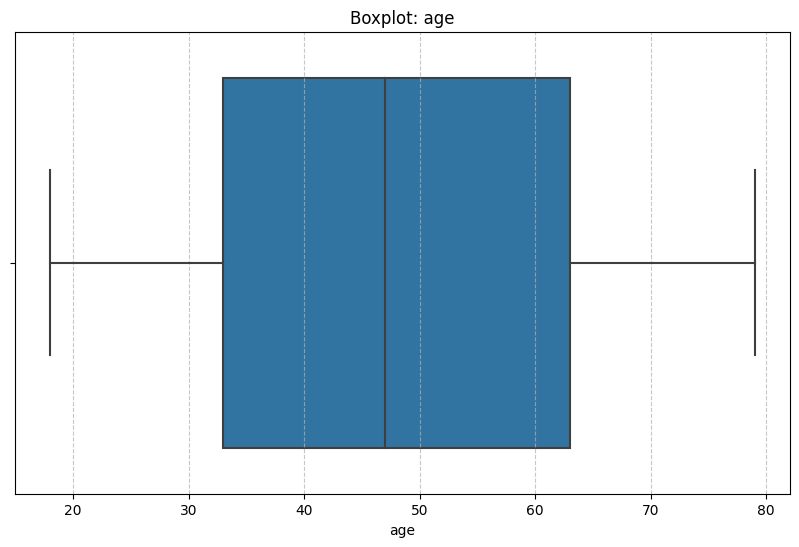

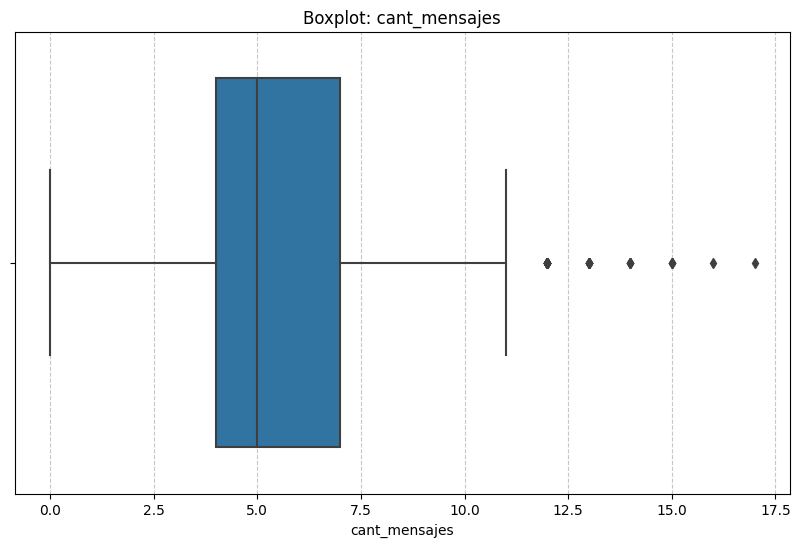

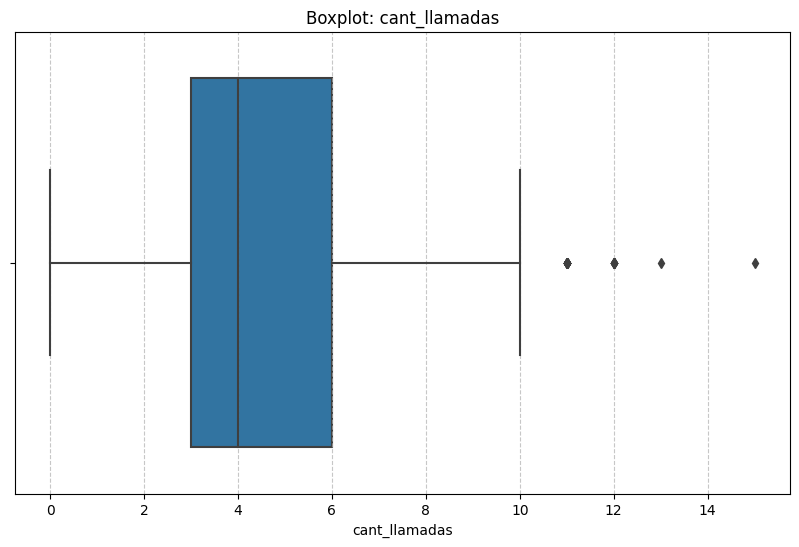

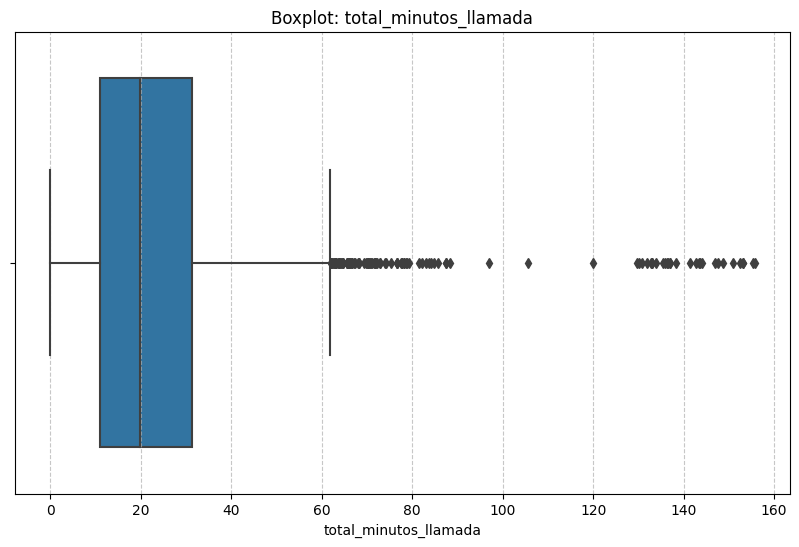

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'total_minutos_llamada']

for col in columnas_numericas:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.grid(True, axis='x', linestyle='--', alpha=0.7)
    plt.show()

💡Insights:

- Age: No presenta outliers. La distribución es diversa pero se mantiene dentro de los 17 y 80 años, por lo que no se requiere ninguna acción de limpieza o transformación, y los datos pueden usarse directamente.

- cant_mensajes: Si presenta outliers. Se observan valores atípicos a partir de los 12 mensajes aproximadamente. Estos representan usuarios que envían una cantidad superior de mensajes en comparación al comportamiento promedio estándar del resto.

- cant_llamadas: Presenta outliers moderados. Se pueden observar puntos aislados por encima de las 11 llamadas. La mayoría de los usuarios realiza entre 3 y 6 llamadas. Los valores en 15 llamadas son atípicos pero posibles.

- total_minutos_llamada: Presenta una alta cantidad de outliers. Esta variable muestra un sesgo a la derecha muy marcado. Mientras que el 75% de los usuarios habla menos de 30 minutos, existe un segmento considerable que llega hasta los 160 minutos. Esto, refleja un un comportamiento de uso intensivo de un segmento de usuarios.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','total_minutos_llamada']
for col in columnas_limites:
    print(f"\n--- Análisis de outliers para {col} ---")
    Q1 = user_profile[col].quantile(0.25)
    print('Primer cuartil: ', Q1)
    Q3 = user_profile[col].quantile(0.75)
    print('Tercer cuartil: ', Q3)
    IQR = Q3 - Q1
    print('IQR: ', IQR)
# Calcular límites para outliers
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    print(f'Límite inferior: {limite_inferior}')
    print(f'Límite superior: {limite_superior}')


--- Análisis de outliers para cant_mensajes ---
Primer cuartil:  4.0
Tercer cuartil:  7.0
IQR:  3.0
Límite inferior: -0.5
Límite superior: 11.5

--- Análisis de outliers para cant_llamadas ---
Primer cuartil:  3.0
Tercer cuartil:  6.0
IQR:  3.0
Límite inferior: -1.5
Límite superior: 10.5

--- Análisis de outliers para total_minutos_llamada ---
Primer cuartil:  11.1075
Tercer cuartil:  31.4125
IQR:  20.305
Límite inferior: -19.35
Límite superior: 61.870000000000005


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,total_minutos_llamada
count,4000.000000,4000.000000,4000.000000
mean,5.523000,4.477000,23.311225
std,2.359738,2.145139,18.169564
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.107500
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.412500
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: Dado que son pocos y no parecen errores de sistema (son valores posibles), se recomienda mantenerlos para no perder información sobre usuarios "heavy users", a menos que el modelo a utilizar sea muy sensible a la varianza.
- cant_llamadas: Se sugiere revisar la correlación con la duración de las mismas. Si son llamadas reales, se conservan.
- total_minutos_llamada:  Al ser una cantidad importante de datos, eliminarlos sesgaría el análisis de ingresos o consumo. Se recomienda realizar una segmentación para separar a los usuarios promedio de los usuarios de alto consumo.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def segmentar_uso(fila):
    llamadas = fila['cant_llamadas']
    mensajes = fila['cant_mensajes']

    if llamadas < 5 and mensajes < 5:
        return 'Bajo uso'
    elif llamadas < 10 and mensajes < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(segmentar_uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,total_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def segmentar_edad(age):
    if age < 30:
        return 'Joven'
    elif age < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

# Aplicamos la función a la columna age
user_profile['grupo_edad'] = user_profile['age'].apply(segmentar_edad)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,total_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

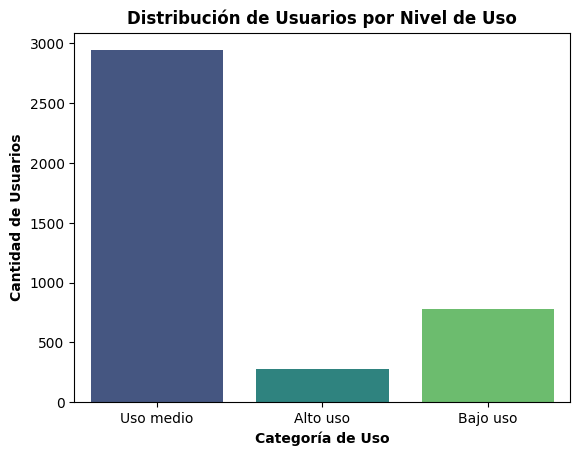

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis')
plt.title('Distribución de Usuarios por Nivel de Uso',fontweight='bold')
plt.xlabel('Categoría de Uso',fontweight='bold')
plt.ylabel('Cantidad de Usuarios',fontweight='bold')
plt.show()

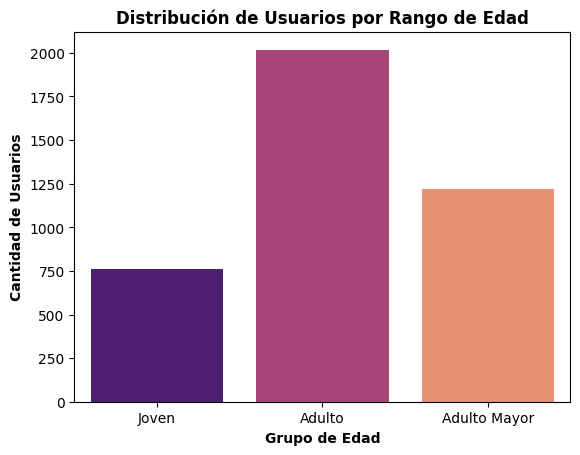

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette='magma', order=['Joven', 'Adulto', 'Adulto Mayor'])
plt.title('Distribución de Usuarios por Rango de Edad',fontweight='bold')
plt.xlabel('Grupo de Edad',fontweight='bold')
plt.ylabel('Cantidad de Usuarios',fontweight='bold')
plt.show()


---

## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?


✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Se encontraron valores nulos en el dataframe users, columna city, lo que impide un análisis segmentado por regiones completo, aunque solo es del 11% y pueden tratarse como NaN o ver la manera de poder recuperarlos.
- Se encontraron valores nulos en el dataframe users, columna churn date, mayores al 80%, lo cual es bueno ya que no todos los clientes se ha dado de baja del servicio, y detectar a los que sí, nos permite generar estrategías de retención y ofrecimiento de planes de acuerdo a su uso.
- Se encontraron valores nulos MAR en el dataframe usage, columnas duration y length, que dependen entre sí y se complementaron como NaN.
- Se encontraron valores nulos en el dataframe usage, columna date menores al 2%, que pueden ser eliminados.
- Se detectaron sentinels en la columna age y city del dataframe users, los cuales fueron remplazados por valores NaN.
- Se convirtieron las columnas de fecha a tipo fecha, en el daframe users y usage y se detectaron valores imposibles los cuales se convirtieron a NaT.
- Se creo una tabla agregada que agrupa a los usuarios por comportamiento de uso (cantidad de mensajes, cantidad de llamadas, y total de minutos en llamadas), y se combino con el dataframe users.
-Se detectaron outliers en las nuevas columnas cantidad de mensajes, cantidad de llamadas, y total de minutos en llamadas, que no fueron remplazados, ya que representan información valiosa para el análisis del comportamiento de los usuarios y su segmentación.

🔍 **Segmentos por Edad**

- Se segmentaron los usuarios por rango de edad en 3 segmentos clave (Joven, Adulto y  Adulto Mayor).
Se observa en las gráficas que la mayor cantidad de usuarios se concentra entre las edades de 30 y 59 años, seguido de adultos mayores con edades mayores a los 60 años y dejando al final a jóvenes con edades menores a 30 años.

📊 **Segmentos por Nivel de Uso**

- Se pueden observar que la mayoría de usuarios tiene un uso medio de mensajes y llamadas, pero también se han detectado dos grupos importantes:
- El Segmento de usuarios con alta cantidad de mensajes: Clientes que, independientemente de su edad, superan los 12 mensajes promedio. Este grupo es pequeño pero muestra una necesidad superior.
- El Segmento de usuarios con altos minutos por llamada: Clientes que superan los 60 minutos por llamada, y con duraciones de hasta 120 minutos en una sola llamada.
  
➡️ Esto sugiere que ...

- Los segmentos más valiosos para ConnectaTel son el segmento Adulto y los clientes con altos minutos por llamada, ya que los clientes Adultos ofrecen estabilidad y baja tasa de cancelación (churn), mientras que los usuarios con altos minutos de llamada representan clientes cuyas necesidades actuales superan los planes básicos y una oportunidad para ofrecerles una migración hacia planes premium o una restructuración a planes ilimitados por llamadas.

💡 **Recomendaciones**
- Lanzar un plan de llamadas ilimitadas, diseñado específicamente para capturar a los usuarios detectados como outliers en minutos de llamada, garantizando ingresos fijos elevados.
- Crear paquetes de mensajería adicional, diseñados para los usuarios que tienen a rebasar la cantidad de SMS de su plan actual, en donde se les ofrezca una vez que se les agotan los mensajes de su plan principal, por ejemplo, 100 SMS por un precio bajo, evitando que el salto a Premium ($25) se perciba como muy costoso.
- Implementar promociones de retención para el grupo Adulto, enfocadas en la estabilidad del servicio de llamadas, que es su principal canal de comunicación.
- Implementrar programas de fidelización por antigüedad para cada segmento de edad, ya que se observó una base sólida registrada desde 2022. Crear promociones para usuarios con >2 años de antigüedad podría reducir el churn.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`